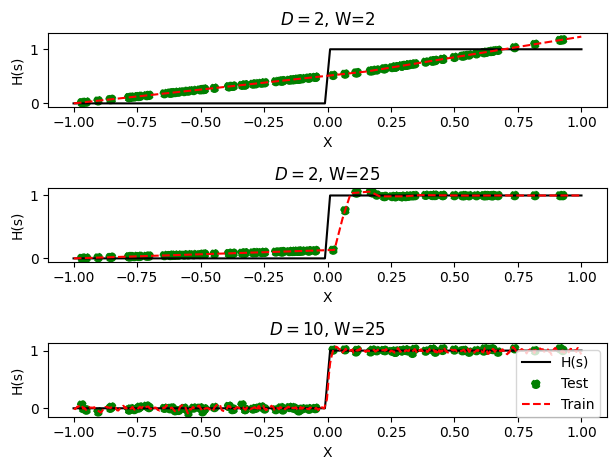

         2791770 function calls (2644842 primitive calls) in 5.989 seconds

   Ordered by: call count

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
   407101    0.057    0.000    0.074    0.000 {built-in method builtins.isinstance}
69938/31409    0.053    0.000    0.211    0.000 {method 'format' of 'str' objects}
62093/61907    0.030    0.000    0.066    0.000 {built-in method builtins.getattr}
    55204    0.008    0.000    0.008    0.000 {method 'append' of 'list' objects}
    52536    0.012    0.000    0.020    0.000 {method 'get' of 'dict' objects}
51757/8967    0.071    0.000    0.094    0.000 ir.py:321(_rec_list_vars)
    42550    0.005    0.000    0.005    0.000 {method 'extend' of 'list' objects}
42441/18215    0.031    0.000    0.202    0.000 _utils.py:44(__str__)
34570/33516    0.006    0.000    0.006    0.000 {built-in method builtins.len}
    31795    0.008    0.000    0.008    0.000 {method 'startswith' of 'str' objects}
31695/31595    0.024    0

In [5]:
import numpy as np
from numpy.typing import NDArray
import matplotlib.pyplot as plt
from matplotlib import cm
from nonlinear_approximator import (
    activations,
    inference,
    model,
    params,
    training, 
)
import numba
import cProfile
from scipy.stats import qmc
from sklearn.linear_model import Ridge, RidgeCV, Lasso
%matplotlib inline

# Parameters 
config1 = params.RegressionParams(
    width=2,
    depth=2,
    input_dimension=1,
    transform_type=activations.TransformType.TENT,
    transform_params= params.TentParams(mu=1.99),
    output_dimension=1,
)

config2 = params.RegressionParams(
    width=25,
    depth=2,
    input_dimension=1,
    transform_type=activations.TransformType.TENT,
    transform_params= params.TentParams(mu=1.99),
    output_dimension=1,
)

config3 = params.RegressionParams(
    width=25,
    depth=10,
    input_dimension=1,
    transform_type=activations.TransformType.TENT,
    transform_params= params.TentParams(mu=1.99),
    output_dimension=1,
)

def gen_neurons(dimension, number):
    sampler = qmc.LatinHypercube(d=dimension)
    sample = sampler.random(n=number) 
    
    return sample
def rmse(x, y):
    return np.mean(np.abs(x.squeeze()-y.squeeze()))
    return np.sqrt(np.mean(np.square(x - y)))
    
@numba.jit(nopython=True)
def tent(x, mu=1.99):
    nonlinear_params = {"alpha": 900, "beta": -0.06045, "r": 3.99, "mu": 1.99}

    # return np.exp(-900 * np.square(x)) + -0.06045
    return mu * np.minimum(x, 1 - x)

def step(x):
    out = np.zeros_like(x)
    out[x > 0] = 1
    out[x == 0] = .5
    return out

@numba.jit(nopython=True)
def compute_activations(neurons, input_x, depth, width):
    num_samples, dim_input = input_x.shape
    # neurons have dim_input x config.width shape
    activations = np.zeros((num_samples, depth, width))
    for idx_sample in range(num_samples):
        for idx_layer in range(depth):
            if idx_layer == 0:
                sample =  np.expand_dims(input_x[idx_sample, :], axis=-1)
                activations[idx_sample, idx_layer, :] = .5*(sample+1).T @ neurons#1 - np.linalg.norm(neurons - sample,axis=0)/(2 * np.sqrt(dim_input))

            else:
                activations[idx_sample, idx_layer, :] = tent(
                    activations[idx_sample, idx_layer - 1, :]
                )
    return activations

@numba.jit(nopython=True)        
def flatten_activations(acts: NDArray[np.floating]) -> NDArray[np.floating]:
    num_samples, depth, width = acts.shape
    flattened = np.zeros((num_samples, depth * width), dtype=np.float64)
    for idx_sample in range(num_samples):
        flattened[idx_sample, :] = np.copy(np.ravel(acts[idx_sample, :, :]))
    return flattened

@numba.jit(nopython=True)
def accum(input_x, output_y, neurons, depth, width):
    batch_size = 256
    n_samples = input_x.shape[0]
    batch_xs = np.array_split(input_x, n_samples // batch_size, axis=0)
    batch_ys = np.array_split(output_y, n_samples // batch_size, axis=0)
    DW = depth * width
    AtA = np.zeros((DW, DW))
    Atb = np.zeros((DW,1))
    for batch_x, batch_y in zip(batch_xs, batch_ys):
        A_batch = flatten_activations(compute_activations(
            neurons, input_x=batch_x, depth=depth, width=width
        ))
        AtA += A_batch.T @ A_batch
        Atb += A_batch.T @ batch_y
    return AtA, Atb
with cProfile.Profile() as pr:
    xs = np.expand_dims(np.linspace(-1, 1, 100),axis=-1)
    xs_train =np.random.uniform(-1, 1, (1000,1) ) 
    xs_test = np.random.uniform(-1, 1, (100,1) )
    plt.figure('h')
    plt.clf()

    for idx, config in enumerate([ config1, config2, config3]):
        plt.subplot(3,1,idx+1)
        plt.plot(xs, step(xs), label='H(s)', c='black')


        neurons = gen_neurons(config.input_dimension, config.width).T

        # zero mean input
        acts_train = compute_activations(
            neurons=neurons, input_x=xs_train, depth=config.depth, width=config.width
        )
        acts_test = compute_activations(
            neurons=neurons, input_x=xs_test, depth=config.depth, width=config.width
        )
        acts_train_flat = flatten_activations(acts_train)
        acts_test_flat = flatten_activations(acts_test)

        AtA, Atb = accum(input_x=xs_train, output_y=step(xs_train), neurons=neurons, depth=config.depth, width=config.width )
        clf = Ridge(alpha=1e-3, tol=1e-16)
        # clf = Lasso(alpha=1e-5)
        clf.fit(AtA, Atb)
        truth_test = step(xs_test)
        preds = clf.predict(acts_test_flat)
        preds_fit = clf.predict(acts_train_flat)
        # if idx == 2:
        #     # inset Axes....
        #     x1, x2, y1, y2 = -1, -0.7, -.003, 0.004  # subregion of the original image
        #     ax = plt.gca()
        #     axins = ax.inset_axes(
        #         [0.15, 0.45, 0.2, 0.5],
        #         xlim=(x1, x2), ylim=(y1, y2))
        #     axins.plot(xs, preds, ls='dotted', c='g')
        #     axins.plot(xs, step(xs), label='H(x)', c='black')
            

        #     ax.indicate_inset_zoom(axins, edgecolor="black", )
        #     axins.ticklabel_format(style='scientific', axis='both', scilimits=(0, 0))

        sortidx_train = np.argsort(xs_train,axis=0)
        sortidx_test = np.argsort(xs_test, axis=0)
        
        truth_test = truth_test[sortidx_test].squeeze()
        
        # err = rmse(truth_test[sortidx_test], preds[sortidx_test]) 
        plt.scatter(xs_test[sortidx_test].squeeze(), preds[sortidx_test].squeeze(), ls='--', c='g', label='Test')
        plt.plot(xs_train[sortidx_train].squeeze(), preds_fit[sortidx_train].squeeze(), ls='--', c='r', label='Train')
        plt.xlabel("X")
        plt.ylabel("H(s)")
        plt.title(f"$D={config.depth}$, W={config.width}")

    plt.legend()
    plt.gcf().tight_layout()
    plt.ion()
    plt.show()

    pr.print_stats(sort='ncalls')